<a href="https://colab.research.google.com/github/juleskantzer/kaggle/blob/main/s6/s6e1_Student_Test_Scores.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import gdown
import pandas as pd


# Create the directory for storing files
DATA_DIR = "data"
os.makedirs(DATA_DIR, exist_ok=True)

# Google Drive file IDs (replace with actual IDs)
TRAIN_FILE_ID = "1Pg7Unltwg29J90fLl6BfutiRtrgpn2yC"
TEST_FILE_ID = "1pbmwqwqAdCu1QmCOzQdXSaSvvu6sIY1I"

# File paths
train_output = os.path.join(DATA_DIR, "train.csv")
test_output = os.path.join(DATA_DIR, "test.csv")

# Download train.csv
print("📥 Downloading train.csv...")
gdown.download(f"https://drive.google.com/uc?id={TRAIN_FILE_ID}", train_output, quiet=False)

# Download test.csv
print("📥 Downloading test.csv...")
gdown.download(f"https://drive.google.com/uc?id={TEST_FILE_ID}", test_output, quiet=False)

# Load into Pandas DataFrame
print("📊 Loading data into DataFrames...")
df_train = pd.read_csv(train_output,index_col="id")
df_test = pd.read_csv(test_output,index_col="id")

# Confirm shapes
print("\n✅ Files downloaded successfully!")
print(f"Train shape: {df_train.shape}")
print(f"Test shape: {df_test.shape}")

📥 Downloading train.csv...


Downloading...
From: https://drive.google.com/uc?id=1Pg7Unltwg29J90fLl6BfutiRtrgpn2yC
To: /kaggle/working/data/train.csv
100%|██████████| 46.0M/46.0M [00:00<00:00, 89.8MB/s]


📥 Downloading test.csv...


Downloading...
From: https://drive.google.com/uc?id=1pbmwqwqAdCu1QmCOzQdXSaSvvu6sIY1I
To: /kaggle/working/data/test.csv
100%|██████████| 18.4M/18.4M [00:00<00:00, 178MB/s]


📊 Loading data into DataFrames...

✅ Files downloaded successfully!
Train shape: (630000, 12)
Test shape: (270000, 11)


# Exploration data analysis


In [ ]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 630000 entries, 0 to 629999
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   age               630000 non-null  int64  
 1   gender            630000 non-null  object 
 2   course            630000 non-null  object 
 3   study_hours       630000 non-null  float64
 4   class_attendance  630000 non-null  float64
 5   internet_access   630000 non-null  object 
 6   sleep_hours       630000 non-null  float64
 7   sleep_quality     630000 non-null  object 
 8   study_method      630000 non-null  object 
 9   facility_rating   630000 non-null  object 
 10  exam_difficulty   630000 non-null  object 
 11  exam_score        630000 non-null  float64
dtypes: float64(4), int64(1), object(7)
memory usage: 62.5+ MB


- no null values
- 5 int 7 strings

In [ ]:
df_train.describe()

,age,study_hours,class_attendance,sleep_hours,exam_score
count,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000
mean,20.545821,4.002337,71.987261,7.072758,62.506672
std,2.260238,2.359880,17.430098,1.744811,18.916884
min,17.000000,0.080000,40.600000,4.100000,19.599000
25%,19.000000,1.970000,57.000000,5.600000,48.800000
50%,21.000000,4.000000,72.600000,7.100000,62.600000
75%,23.000000,6.050000,87.200000,8.600000,76.300000
max,24.000000,7.910000,99.400000,9.900000,100.000000


- High school Class
- Notation max 100
- some data are per/day


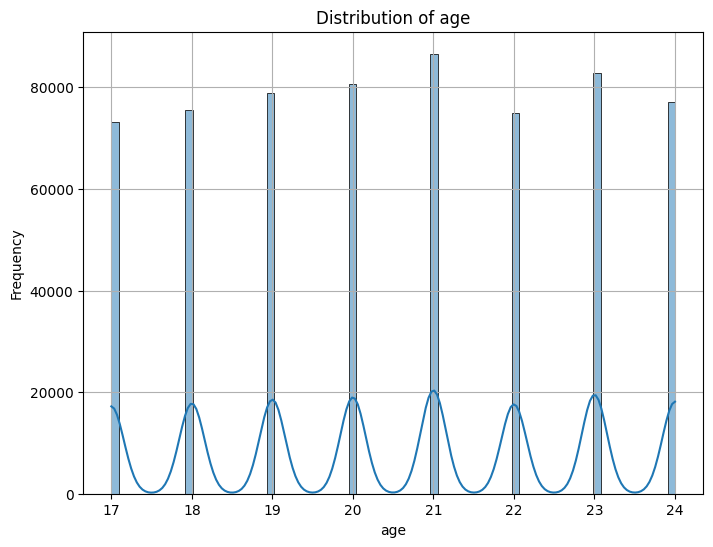

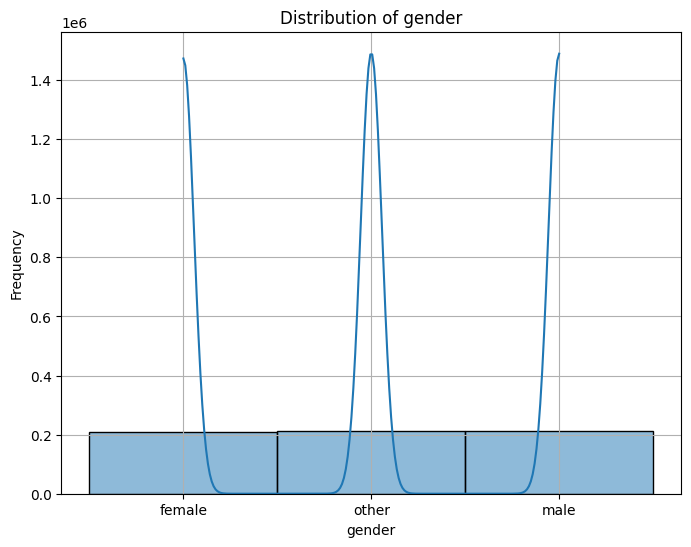

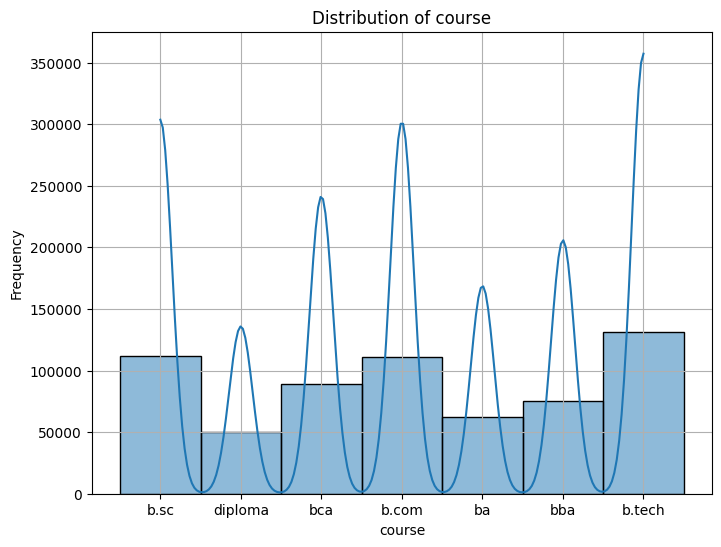

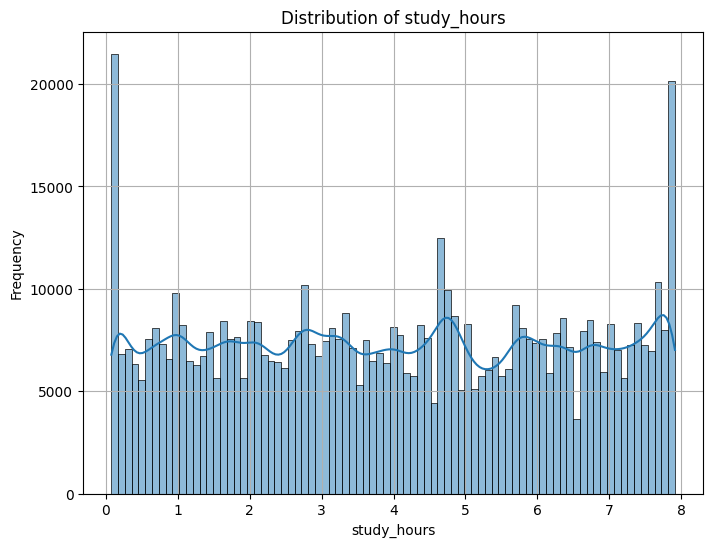

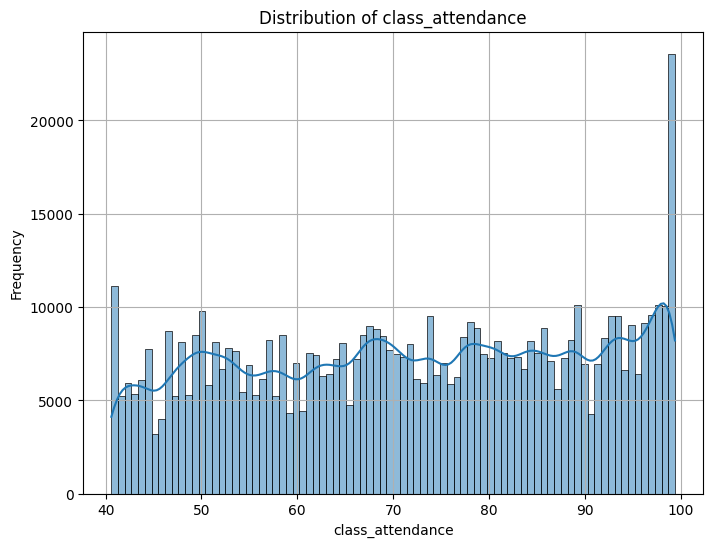

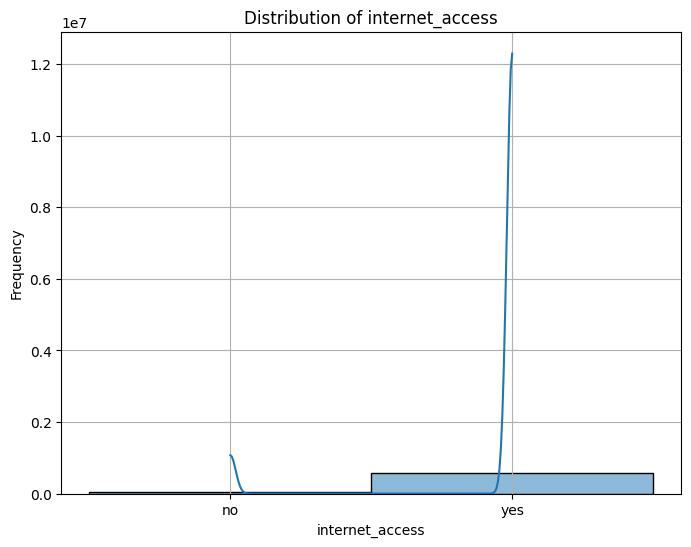

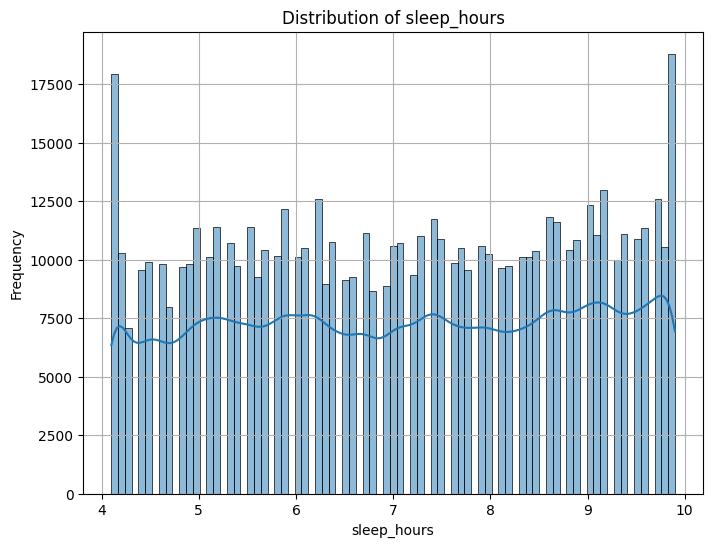

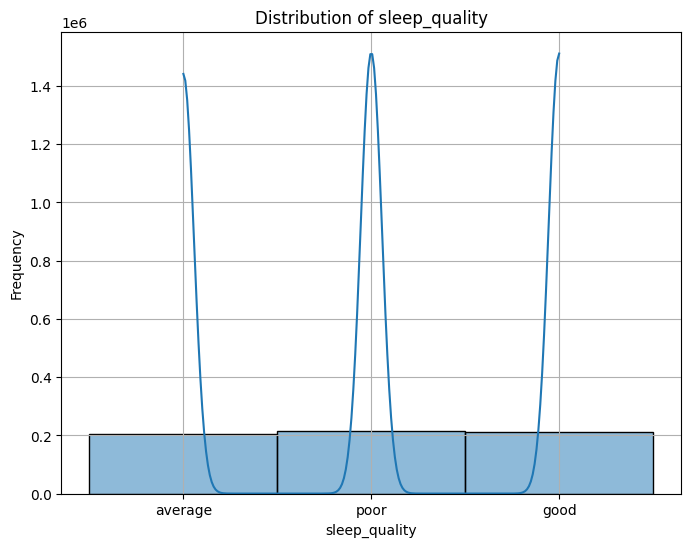

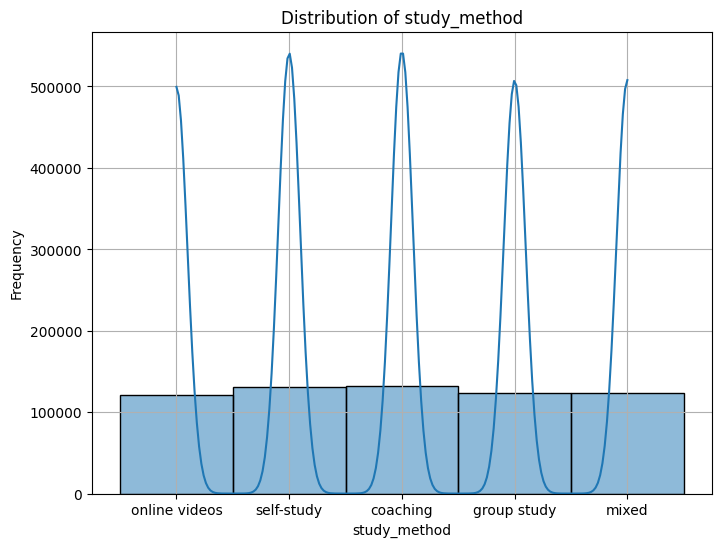

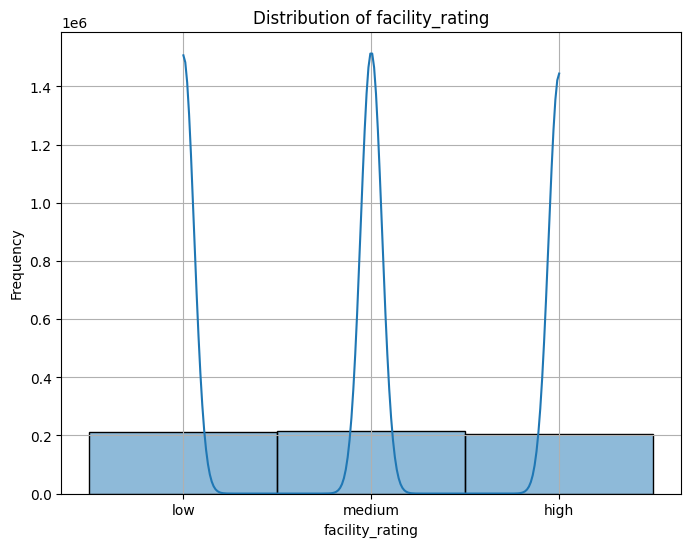

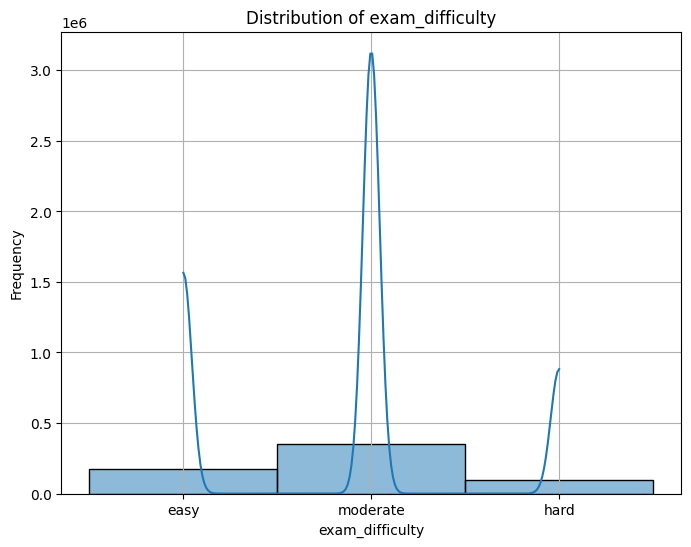

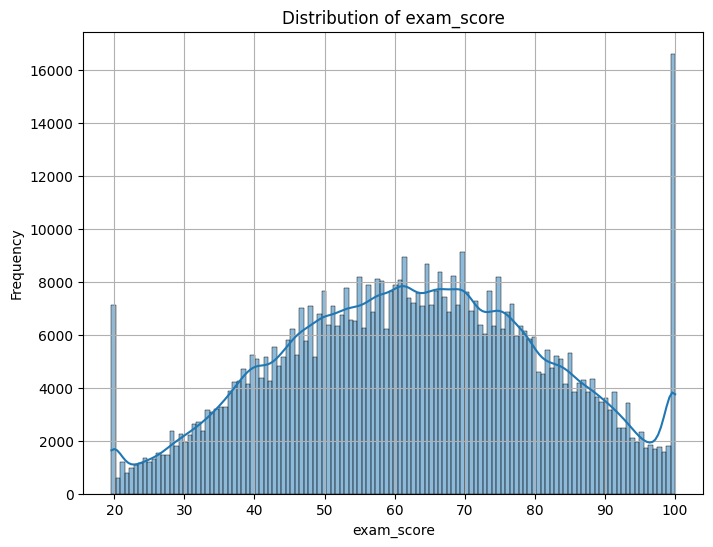

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

for col in df_train.columns:
   plt.figure(figsize=(8, 6))
   sns.histplot(df_train[col], kde=True)
   plt.title(f'Distribution of {col}')
   plt.xlabel(col)
   plt.ylabel('Frequency')
   plt.grid(True)
   plt.show()



- distribution are gennerally flat
- 2 extremum with a lot of frequency

Text(0.5, 1.0, 'Correlation Heatmap')

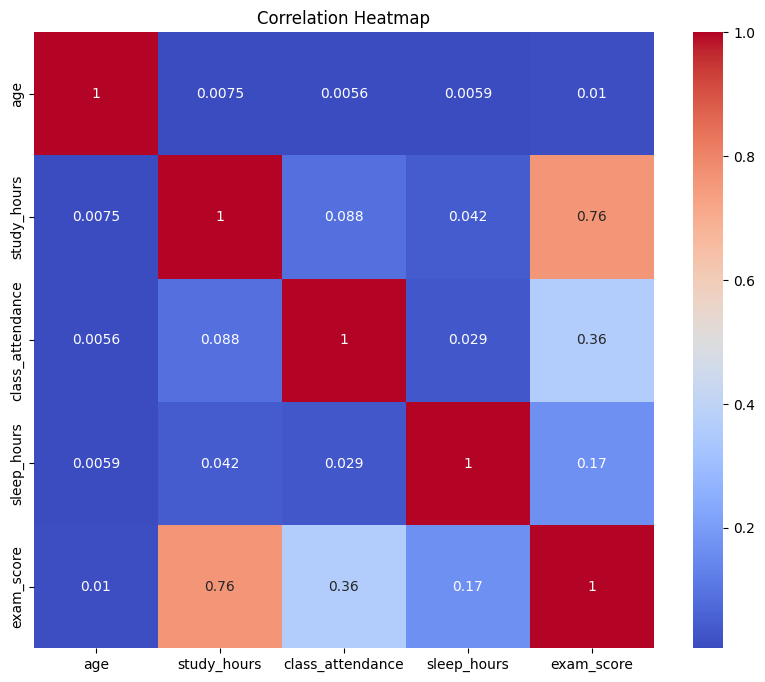

In [ ]:
import matplotlib.pyplot as plt
# heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df_train.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')



In [ ]:
df_train["exam_score"]

id
0          78.300
1          46.700
2          99.000
3          63.900
4         100.000
           ...   
629995     69.500
629996     78.900
629997     19.599
629998     59.100
629999     37.200
Name: exam_score, Length: 630000, dtype: float64

- daily study hours very corelated with exam score

In [ ]:
def plot_features_dual_axis(
    df: pd.DataFrame,
    cols: list[str],
    target_col: str,
    n_bins: int = 10,
    n_wide: int = 3,
    figsize_per_plot: tuple[float, float] = (5, 4),
    int_as_cat_unique_max: int | None = 20,
    cat_order: dict[str, list] | None = None,   # <-- NEW
):
    BAR_COLOR = "tab:blue"
    LINE_COLOR = "tab:orange"

    def is_categorical(s: pd.Series) -> bool:
        return s.dtype == "object" or pd.api.types.is_string_dtype(s)

    n_cols = len(cols)
    n_rows = int(np.ceil(n_cols / n_wide))

    fig, axes = plt.subplots(
        n_rows,
        n_wide,
        figsize=(figsize_per_plot[0] * n_wide, figsize_per_plot[1] * n_rows),
    )

    axes = np.atleast_1d(axes).ravel()

    for i, col in enumerate(cols):
        ax1 = axes[i]
        col_safe = col.replace("_", r"\_")

        n_nan = df[col].isna().sum()
        n_unique = df[col].nunique(dropna=True)

        tmp = df[[col, target_col]].dropna()
        if tmp.empty:
            ax1.set_title(
                rf"$\bf{{{col_safe}}}$"
                f"\n(empty after dropna; {n_unique} unique, {n_nan} nan)"
            )
            continue

        x = tmp[col]
        y = tmp[target_col]

        # ---------- TRUE CATEGORICAL ----------
        if is_categorical(x):
            type_str = "categorical"

            # base counts / means
            counts = x.value_counts()
            mean_y = tmp.groupby(col)[target_col].mean()

            # ---- APPLY USER-DEFINED CATEGORY ORDER (if provided) ----
            if cat_order is not None and col in cat_order:
                desired = list(cat_order[col])

                # keep only categories present in data
                ordered = [c for c in desired if c in counts.index]

                # append any remaining categories not specified by user
                remaining = [c for c in counts.index if c not in ordered]
                final_order = ordered + remaining
            else:
                final_order = sorted(counts.index)

            counts = counts.loc[final_order]
            mean_y = mean_y.loc[final_order]

            xpos = np.arange(len(final_order))

            ax1.bar(xpos, counts.values, alpha=0.6, color=BAR_COLOR)
            ax1.set_xlabel(col)
            ax1.set_ylabel("Count", color=BAR_COLOR)
            ax1.tick_params(axis="y", colors=BAR_COLOR)

            ax1.set_xticks(xpos)
            ax1.set_xticklabels(final_order, rotation=45, ha="right")

            ax2 = ax1.twinx()
            ax2.plot(xpos, mean_y.values, marker="o", color=LINE_COLOR)
            ax2.set_ylabel(f"Mean {target_col}", color=LINE_COLOR)
            ax2.tick_params(axis="y", colors=LINE_COLOR)

            ax1.set_title(
                rf"$\bf{{{col_safe}}}$: Count vs Mean {target_col}"
                f"\n({type_str} with {n_unique} unique and {n_nan} nan)"
            )

        # ---------- NUMERIC ----------
        else:
            type_str = "numeric"

            xvals = x.values
            yvals = y.values

            mask = np.isfinite(xvals) & np.isfinite(yvals)
            xvals = xvals[mask]
            yvals = yvals[mask]

            if len(xvals) == 0:
                ax1.set_title(
                    rf"$\bf{{{col_safe}}}$"
                    f"\n({type_str} with {n_unique} unique and {n_nan} nan)"
                )
                continue

            unique_vals = np.sort(np.unique(xvals))
            n_unique_eff = len(unique_vals)

            # --- Case 1: int-as-categorical ---
            if int_as_cat_unique_max is not None and n_unique_eff <= int_as_cat_unique_max:
                counts = np.array([(xvals == v).sum() for v in unique_vals])
                mean_y = np.array([yvals[xvals == v].mean() for v in unique_vals])

                xpos = np.arange(n_unique_eff)

                ax1.bar(xpos, counts, alpha=0.6, color=BAR_COLOR)
                ax1.set_xlabel(col)
                ax1.set_ylabel("Count", color=BAR_COLOR)
                ax1.tick_params(axis="y", colors=BAR_COLOR)

                rotate = 45 if n_unique_eff > n_bins else 0
                step = max(int(np.ceil(n_unique_eff / n_bins)), 1)
                tick_idx = np.arange(0, n_unique_eff, step)

                if pd.api.types.is_integer_dtype(x):
                    tick_labels = unique_vals[tick_idx].astype(int)
                else:
                    tick_labels = unique_vals[tick_idx]

                ax1.set_xticks(tick_idx)
                ax1.set_xticklabels(
                    tick_labels,
                    rotation=rotate,
                    ha="right" if rotate else "center",
                )

                ax2 = ax1.twinx()
                ax2.plot(xpos, mean_y, marker="o", color=LINE_COLOR)
                ax2.set_ylabel(f"Mean {target_col}", color=LINE_COLOR)
                ax2.tick_params(axis="y", colors=LINE_COLOR)

                ax1.set_title(
                    rf"$\bf{{{col_safe}}}$: Per-Value Count vs Mean {target_col}"
                    f"\n({type_str} with {n_unique} unique and {n_nan} nan)"
                )

            # --- Case 2: low-cardinality numeric bins ---
            elif n_unique_eff < n_bins:
                counts = np.array([(xvals == v).sum() for v in unique_vals])
                mean_y = np.array([yvals[xvals == v].mean() for v in unique_vals])

                width = 0.8 * (np.min(np.diff(unique_vals)) if n_unique_eff > 1 else 1.0)

                ax1.bar(unique_vals, counts, width=width, alpha=0.6, color=BAR_COLOR)
                ax1.set_xlabel(col)
                ax1.set_ylabel("Count", color=BAR_COLOR)
                ax1.tick_params(axis="y", colors=BAR_COLOR)

                ax2 = ax1.twinx()
                ax2.plot(unique_vals, mean_y, marker="o", color=LINE_COLOR)
                ax2.set_ylabel(f"Mean {target_col}", color=LINE_COLOR)
                ax2.tick_params(axis="y", colors=LINE_COLOR)

                ax1.set_title(
                    rf"$\bf{{{col_safe}}}$: Per-Value Count vs Mean {target_col}"
                    f"\n({type_str} with {n_unique} unique and {n_nan} nan)"
                )

            # --- Case 3: regular histogram ---
            else:
                bins = np.linspace(xvals.min(), xvals.max(), n_bins + 1)
                bin_centers = 0.5 * (bins[:-1] + bins[1:])

                counts, _ = np.histogram(xvals, bins=bins)
                bin_idx = np.digitize(xvals, bins) - 1

                mean_y = np.array([
                    yvals[bin_idx == j].mean() if np.any(bin_idx == j) else np.nan
                    for j in range(n_bins)
                ])

                ax1.bar(
                    bin_centers,
                    counts,
                    width=(bins[1] - bins[0]),
                    alpha=0.6,
                    color=BAR_COLOR,
                )
                ax1.set_xlabel(col)
                ax1.set_ylabel("Count", color=BAR_COLOR)
                ax1.tick_params(axis="y", colors=BAR_COLOR)

                ax2 = ax1.twinx()
                ax2.plot(bin_centers, mean_y, marker="o", color=LINE_COLOR)
                ax2.set_ylabel(f"Mean {target_col}", color=LINE_COLOR)
                ax2.tick_params(axis="y", colors=LINE_COLOR)

                ax1.set_title(
                    rf"$\bf{{{col_safe}}}$: Histogram vs Mean {target_col}"
                    f"\n({type_str} with {n_unique} unique and {n_nan} nan)"
                )

    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()

In [ ]:
df_train.drop("exam_score",axis=1)

,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty
id,,,,,,,,,,,
0,21,female,b.sc,7.91,98.8,no,4.9,average,online videos,low,easy
1,18,other,diploma,4.95,94.8,yes,4.7,poor,self-study,medium,moderate
2,20,female,b.sc,4.68,92.6,yes,5.8,poor,coaching,high,moderate
3,19,male,b.sc,2.00,49.5,yes,8.3,average,group study,high,moderate
4,23,male,bca,7.65,86.9,yes,9.6,good,self-study,high,easy
...,...,...,...,...,...,...,...,...,...,...,...
629995,18,female,b.tech,4.86,70.7,yes,4.1,good,mixed,high,moderate
629996,21,female,ba,7.08,54.4,yes,4.5,average,mixed,low,moderate
629997,24,male,bca,0.64,44.2,yes,4.3,poor,online videos,low,moderate


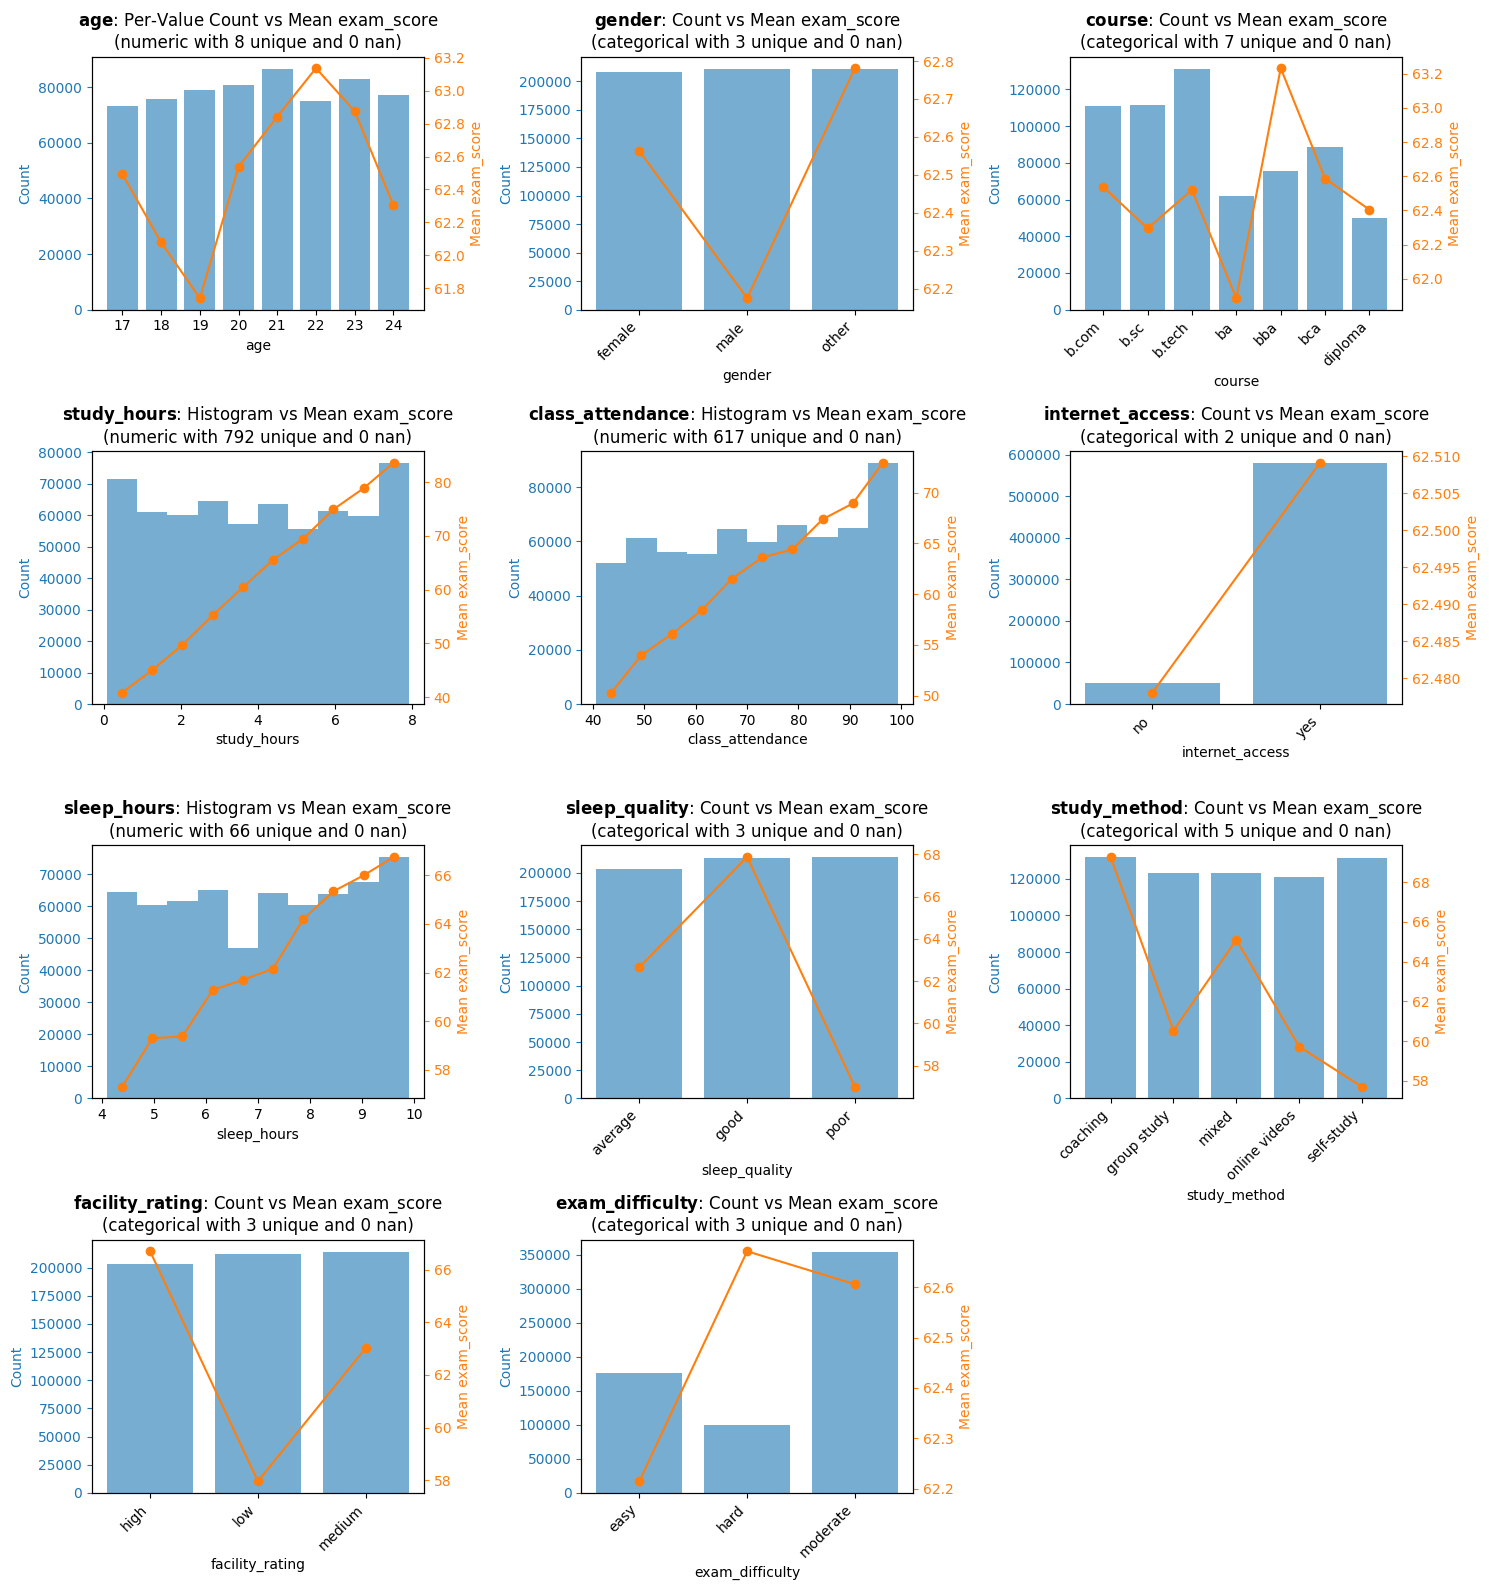

In [ ]:
import numpy as np
plot_features_dual_axis(
    df=df_train,
    cols=df_train.drop("exam_score",axis=1).columns,
    target_col="exam_score",
    n_bins=10,
)

In [ ]:
!pip install catboost

In [ ]:
!pip install optuna

In [ ]:
import pandas as pd
import numpy as np
import optuna

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from catboost import CatBoostRegressor

# -----------------------------
# Données
# -----------------------------
df = df_train

X = df.drop(columns=["exam_score"])
y = df["exam_score"]

cat_features = X.select_dtypes(include=["object", "category"]).columns.tolist()

# -----------------------------
# Split train / valid
# -----------------------------
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 🔥 SOUS-ÉCHANTILLON POUR OPTUNA
SUBSAMPLE_SIZE = 120_000

X_sub, _, y_sub, _ = train_test_split(
    X_train, y_train,
    train_size=SUBSAMPLE_SIZE,
    random_state=42
)

# -----------------------------
# Fonction objectif Optuna (FAST)
# -----------------------------
def objective(trial):

    params = {
        "iterations": trial.suggest_int("iterations", 200, 600),
        "learning_rate": trial.suggest_float("learning_rate", 0.03, 0.2, log=True),
        "depth": trial.suggest_int("depth", 5, 8),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1.0, 10.0, log=True),
        "subsample": trial.suggest_float("subsample", 0.7, 1.0),
        "colsample_bylevel": trial.suggest_float("colsample_bylevel", 0.7, 1.0),
        "loss_function": "RMSE",
        "eval_metric": "RMSE",
        "random_seed": 42,
        "early_stopping_rounds": 50,
        "verbose": 0
    }

    model = CatBoostRegressor(**params)

    model.fit(
        X_sub,
        y_sub,
        cat_features=cat_features,
        eval_set=(X_valid, y_valid),
        use_best_model=True
    )

    y_pred = model.predict(X_valid)
    rmse = np.sqrt(mean_squared_error(y_valid, y_pred))

    return rmse

# -----------------------------
# Optuna (RAPIDE)
# -----------------------------
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=25, show_progress_bar=True)

print("Best params:", study.best_params)
print(f"Best RMSE: {study.best_value:.4f}")


/usr/local/lib/python3.12/dist-packages/sqlalchemy/orm/query.py:195: SyntaxWarning: "is not" with 'tuple' literal. Did you mean "!="?
  if entities is not ():
[I 2026-01-31 22:27:13,314] A new study created in memory with name: no-name-df9eda2c-7ee4-4b03-a340-cb5ca7201ef5
/usr/local/lib/python3.12/dist-packages/optuna/progress_bar.py:47: ExperimentalWarning: Progress bar is experimental (supported from v1.2.0). The interface can change in the future.
  self._init_valid()


  0%|          | 0/25 [00:00<?, ?it/s]

[I 2026-01-31 22:27:37,228] Trial 0 finished with value: 8.836326658850483 and parameters: {'iterations': 345, 'learning_rate': 0.057011711767337374, 'depth': 5, 'l2_leaf_reg': 4.585818005158018, 'subsample': 0.8075191409564514, 'colsample_bylevel': 0.7243853017353523}. Best is trial 0 with value: 8.836326658850483.
[I 2026-01-31 22:28:12,852] Trial 1 finished with value: 8.827560677476113 and parameters: {'iterations': 371, 'learning_rate': 0.07103105409939857, 'depth': 6, 'l2_leaf_reg': 3.0109160965097232, 'subsample': 0.7979429581349546, 'colsample_bylevel': 0.8631937480215897}. Best is trial 1 with value: 8.827560677476113.
[I 2026-01-31 22:29:35,257] Trial 2 finished with value: 8.815989286718775 and parameters: {'iterations': 575, 'learning_rate': 0.043696584767144754, 'depth': 8, 'l2_leaf_reg': 2.8567517857360727, 'subsample': 0.8074591968377619, 'colsample_bylevel': 0.9395353340145379}. Best is trial 2 with value: 8.815989286718775.
[I 2026-01-31 22:30:44,102] Trial 3 finished 

In [ ]:
# =============================
# MODÈLE FINAL (FULL TRAIN)
# =============================
best_params = study.best_params

final_model = CatBoostRegressor(
    **best_params,
    loss_function="RMSE",
    random_seed=42,
    verbose=0
)

# entraînement sur TOUT le train
final_model.fit(
    X,
    y,
    cat_features=cat_features
)

# =============================
# PRÉDICTION SUR df_test
# =============================
X_test = df_test.copy()
test_preds = final_model.predict(X_test)

# =============================
# SUBMISSION KAGGLE
# ⚠️ adapte "id" si besoin
# =============================
submission = pd.DataFrame({
    "id": df_test.index,
    "exam_score": test_preds
})

submission.to_csv("submission.csv", index=False)

print("✅ submission.csv généré")


✅ submission.csv généré


In [ ]:
df_test.columns

Index(['age', 'gender', 'course', 'study_hours', 'class_attendance',
       'internet_access', 'sleep_hours', 'sleep_quality', 'study_method',
       'facility_rating', 'exam_difficulty'],
      dtype='object')

In [ ]:
submission.to_csv("submission.csv", index=False)
